<a href="https://colab.research.google.com/github/jech2nNexus/awesome-openclaw-usecases/blob/main/%E1%84%85%E1%85%A1%E1%84%8B%E1%85%B5%E1%84%87%E1%85%B3_10%E1%84%87%E1%85%AE%E1%86%AB_%E1%84%8B%E1%85%A7%E1%86%BC%E1%84%89%E1%85%A1%E1%86%BC%E1%84%89%E1%85%A2%E1%86%BC%E1%84%89%E1%85%A5%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10분 만에 영상 하나 만들기
### 그림을 만들고, 그 그림을 움직입니다

**AI CITY BUILDERS** · 라이브 실습

---

위에서부터 **재생 버튼 네 번**이면 영상이 나옵니다.

### 오늘 드는 돈 (환율 1,400원 기준)

| | 토큰 | 달러 | 원 |
|---|---|---|---|
| 그림 1장 (나노바나나 프로) | 1,120 | $0.134 | **약 190원** |
| 영상 10초 · 360p | 19,307 | $0.338 | **약 470원** |
| 영상 10초 · 720p | 57,920 | $1.01 | 약 1,420원 |

**오늘 실습(360p) 합계 — 약 660원**

> 영상 생성은 **무료 사용량이 없습니다.** 결제 수단이 등록된 키가 필요합니다.
> 공식 가격: 영상 $17.50 / 100만 토큰 · 이미지 $120 / 100만 토큰


---
# 1 · API 키 넣기

### 아래 따옴표 안에 API 키를 붙여넣고 재생하세요.

키는 [구글 AI 스튜디오](https://aistudio.google.com/apikey) 왼쪽 아래 **API 키**에서 복사합니다.

비워 두고 실행하면 가려진 입력창이 뜹니다. 화면 공유 중이라면 그쪽이 안전합니다.


In [ ]:
# ═══════════════════════════════════════════
API_KEY = ""   # ← 여기에 API 키를 붙여넣으세요
# ═══════════════════════════════════════════

%pip install -q -U "google-genai>=2.0.0"

import getpass, base64, os
from google import genai
from google.genai import types

assert int(genai.__version__.split('.')[0]) >= 2, f'2.0 이상이 필요합니다 (지금 {genai.__version__})'

# 위에 안 넣었으면 코랩 보안 비밀 → 그것도 없으면 가려진 입력창
if not API_KEY:
    try:
        from google.colab import userdata
        API_KEY = userdata.get('GEMINI_API_KEY')
    except Exception:
        API_KEY = getpass.getpass('제미나이 API 키를 붙여넣고 엔터: ')

client = genai.Client(api_key=API_KEY)
print(f'준비 완료 · google-genai {genai.__version__}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.
준비 완료 · google-genai 2.21.0


---
# 2 · 무엇을 만들지 적고, 얼마 드는지 봅니다

**STYLE** 은 영상 전체의 분위기입니다. 장면이 바뀌어도 톤이 흔들리지 않게 잡아 줍니다.
**IMAGE** 는 첫 장면 그림, **VIDEO** 는 그 그림이 어떻게 움직일지입니다.

아래 네 줄만 바꾸면 다른 영상이 나옵니다.


In [ ]:
# ── 여기만 바꾸면 됩니다 ─────────────────────────────
STYLE  = "시네마틱 다큐멘터리, 차가운 청록 색감, 필름 그레인, 사실적 질감, 글자 없음"
IMAGE  = "깊은 바닷속, 침몰선 갑판 위에 금괴 상자가 반쯤 모래에 묻혀 있는 장면. 위에서 들어오는 빛줄기."
VIDEO  = "카메라가 금괴 상자를 향해 천천히 밀고 들어간다. 부유물이 빛 속을 떠다닌다."
SOUND  = "효과음만. 나레이션 없음, 음악 없음."
ASPECT = "9:16"     # 쇼츠는 9:16, 가로 영상은 16:9
QUALITY = "360p"    # 초안은 360p, 최종은 720p
# ────────────────────────────────────────────────

# 만들기 전에 얼마인지 먼저 봅니다 — 이 습관이 제일 중요합니다
USD_KRW = 1400                  # 환율은 그때그때 바꾸세요
IMAGE_KRW = 0.134 * USD_KRW     # 나노바나나 프로 1장 = 1,120토큰
VIDEO_720P_10S = 1.01 * USD_KRW # 720p 10초 = 57,920토큰
RATIO = {'360p': 1/3, '720p': 1.0, '1080p': 1.0, '4k': 1.0}

video_krw = VIDEO_720P_10S * RATIO[QUALITY]
print(f'{QUALITY} · 10초 · {ASPECT}')
print(f'  그림  약 {IMAGE_KRW:,.0f}원')
print(f'  영상  약 {video_krw:,.0f}원')
print(f'  합계  약 {IMAGE_KRW + video_krw:,.0f}원')


360p · 10초 · 9:16
  그림  약 188원
  영상  약 471원
  합계  약 659원


---
# 3 · 첫 그림 만들기

**나노바나나 프로**가 첫 장면을 그립니다. 20초쯤 걸립니다.

비율은 프롬프트 문장이 아니라 **설정값**으로 넘겨야 먹습니다.


그림 완성 · 860KB


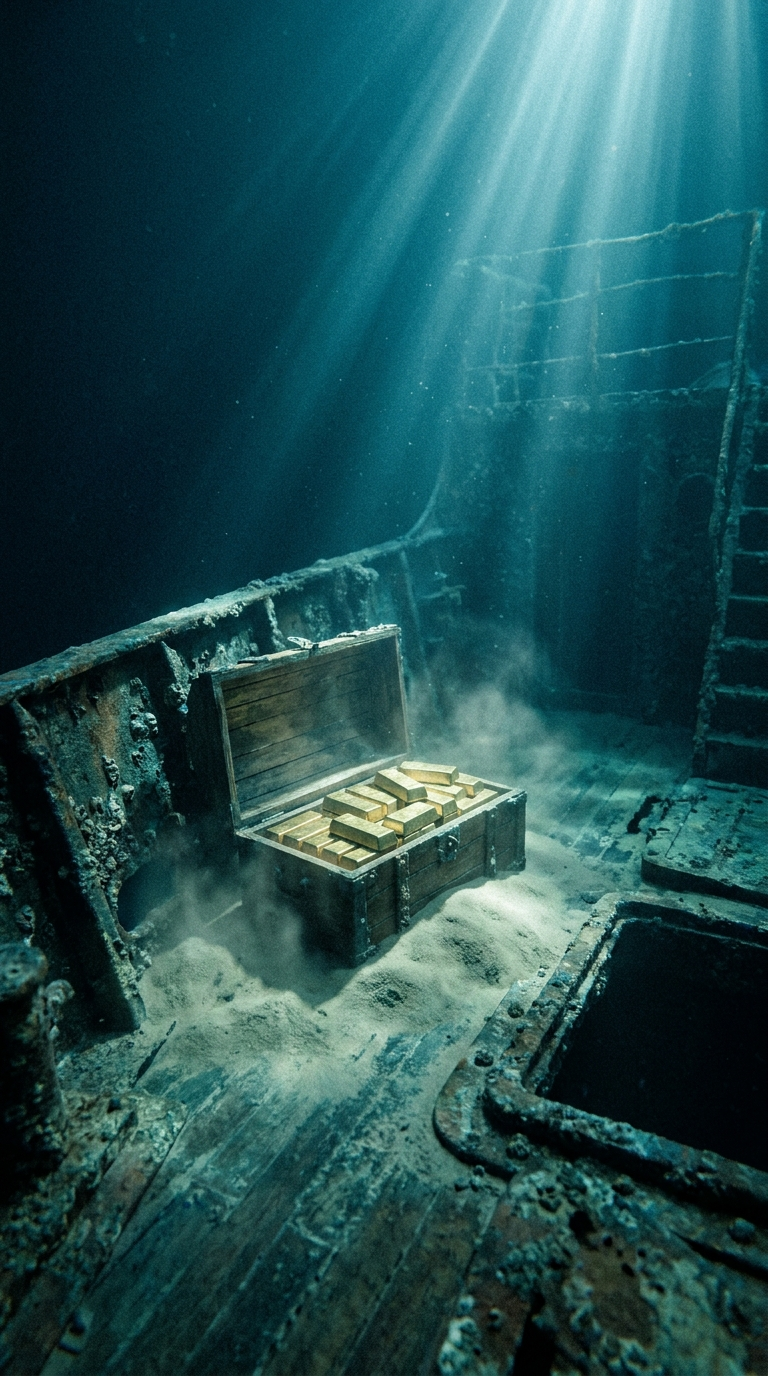

In [ ]:
IMAGE_MODEL = "nano-banana-pro-preview"

res = client.models.generate_content(
    model=IMAGE_MODEL,
    contents=f"{STYLE}. {IMAGE}",
    config=types.GenerateContentConfig(
        image_config=types.ImageConfig(aspect_ratio=ASPECT),
    ),
)

img_bytes = None
for part in res.candidates[0].content.parts:
    if getattr(part, 'inline_data', None):
        img_bytes = part.inline_data.data
        break

assert img_bytes, '이미지가 나오지 않았습니다. 프롬프트를 짧게 줄여 다시 실행해 보세요.'
open('frame.png', 'wb').write(img_bytes)

from IPython.display import Image, display
print(f'그림 완성 · {len(img_bytes)//1024}KB')
display(Image('frame.png', width=300))


---
# 4 · 그림을 움직입니다

방금 만든 그림을 **첫 프레임**으로 넣고, 어떻게 움직일지 말로 적습니다.
30초쯤 걸리고, 10초짜리 영상이 나옵니다.


In [ ]:
VIDEO_MODEL = "gemini-omni-1.1-flash"

print('영상 생성 중… 30초쯤 걸립니다')
r = client.interactions.create(
    model=VIDEO_MODEL,
    input=[
        {'type': 'image', 'data': base64.b64encode(img_bytes).decode(), 'mime_type': 'image/png'},
        {'type': 'text',  'text': f'{VIDEO} {SOUND}'},
    ],
    response_format={'type': 'video', 'resolution': QUALITY, 'aspect_ratio': ASPECT},
)

open('scene.mp4', 'wb').write(base64.b64decode(r.output_video.data))
print(f"완성 · scene.mp4 ({os.path.getsize('scene.mp4')//1024}KB)")

# 실제로 쓴 토큰 — 청구서와 맞춰 볼 수 있습니다
u = r.usage
print(f'쓴 토큰: {u.total_tokens:,}  (영상 출력 {u.output_tokens_by_modality[0].tokens:,})')
print(f'실제 비용: 약 {u.total_output_tokens * 17.5 / 1_000_000 * USD_KRW:,.0f}원')

from IPython.display import Video
display(Video('scene.mp4', embed=True, width=300))


영상 생성 중… 30초쯤 걸립니다
완성 · scene.mp4 (2161KB)
쓴 토큰: 21,416  (영상 출력 19,310)
실제 비용: 약 488원


---
## 내려받기

아래를 실행하면 `scene.mp4` 가 컴퓨터로 저장됩니다. 캡컷에 넣으면 됩니다.


In [ ]:
from google.colab import files
files.download('scene.mp4')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 막히면

| 증상 | 이유와 해결 |
|---|---|
| `legacy Interactions API schema` | `google-genai` 가 2.0 미만입니다. 1번 셀을 다시 실행하고 런타임을 재시작하세요 |
| `401` · `UNAUTHENTICATED` | 키가 잘못됐거나 만료됐습니다. AI 스튜디오에서 다시 받으세요 |
| `403` · `PERMISSION_DENIED` | 키에 결제 수단이 연결되지 않았습니다. 구글 클라우드 콘솔 결제 메뉴에서 등록하세요 |
| 이미지가 안 나옴 | 프롬프트가 너무 깁니다. 한 문장으로 줄여 보세요 |
| 비율이 안 맞음 | 프롬프트 문장이 아니라 `ASPECT` 설정값을 바꿔야 합니다 |

**쓴 돈 확인** — 구글 AI 스튜디오의 **Spend** 화면에서 지금까지 나간 금액을 볼 수 있습니다.
만들 때마다 확인하는 습관을 들이세요.

---

## 다음

장면을 이어 붙여 40초까지 만들고, 나레이션과 자막을 합치고, 유튜브에 자동으로 올리는 것까지는
**8월 「AI 콘텐츠 자동화의 정석」** 에서 다룹니다.

여기서 쓴 분석 · 기획 · 나레이션을 **내 컴퓨터에서 0원으로** 돌리는 방법은
**9월 「나만의 인공지능 — 로컬AI의 정석」** 에서 다룹니다.

*AI CITY BUILDERS · www.aicitybuilders.com*
